In [19]:
import h5py
import pandas as pd
tree_file = r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\TNG300-1\output\tree_617680.hdf5"

with h5py.File(tree_file, "r") as f:
    tree = pd.DataFrame({
        "TreeID": f["TreeID"][:],
        "SnapNum": f["SnapNum"][:],
        "SubhaloID": f["SubhaloID"][:],
        "SubfindID": f["SubfindID"][:],
        "FirstProgenitorID": f["FirstProgenitorID"][:],
        "NextProgenitorID": f["NextProgenitorID"][:],
        "DescendantID": f["DescendantID"][:],
        "SubhaloMass": f["SubhaloMass"][:],
        "SubhaloMassInRad": f["SubhaloMassInRad"][:],
        "SubhaloHalfmassRad": f["SubhaloHalfmassRad"][:],
    })

print(tree.sort_values("SnapNum").to_string(index=False))

            TreeID  SnapNum          SubhaloID  SubfindID  FirstProgenitorID   NextProgenitorID       DescendantID  SubhaloMass  SubhaloMassInRad  SubhaloHalfmassRad
200000007700000000        5 200000007700042726    1754418                 -1                 -1 200000007700042725     0.091279          0.000000           19.280420
200000007700000000        7 200000007700042725    3103757 200000007700042726                 -1 200000007700042724     0.099060          0.000000           19.095232
200000007700000000        8 200000007700042724    2276909 200000007700042725                 -1 200000007700042723     0.165042          0.000000           23.723713
200000007700000000        9 200000007700042723    3038543 200000007700042724                 -1 200000007700042722     0.159765          0.000000           20.564846
200000007700000000       10 200000007700042722    2473271 200000007700042723                 -1 200000007700042721     0.213291          0.000000           19.337450
2000

In [20]:
import numpy as np

tree_file = r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\TNG300-1\output\tree_617680.hdf5"

with h5py.File(tree_file, "r") as f:
    snap = f["SnapNum"][:]
    subhalo_id = f["SubhaloID"][:]
    subhalo_mass = f["SubhaloMass"][:]
    subhalo_mass_in_rad = f["SubhaloMassInRad"][:]
    halfmass_rad = f["SubhaloHalfmassRad"][:]
    group_id = f["SubhaloGrNr"][:]
    mass_type = f["SubhaloMassType"][:]
    mass_in_rad_type = f["SubhaloMassInRadType"][:]
    gas_mass = mass_type[:, 0]
    dm_mass = mass_type[:, 1]
    star_mass = mass_type[:, 4]

    gas_mass_in_rad = mass_in_rad_type[:, 0]
    dm_mass_in_rad = mass_in_rad_type[:, 1]
    star_mass_in_rad = mass_in_rad_type[:, 4]
tree = pd.DataFrame({
    "SnapNum": snap,
    "SubhaloID": subhalo_id,
    "SubhaloMass": subhalo_mass,
    "SubhaloMassInRad": subhalo_mass_in_rad,
    "GasMass": gas_mass,
    "DMMass": dm_mass,
    "StarMass": star_mass,
    "GasMassInRad": gas_mass_in_rad,
    "DMMassInRad": dm_mass_in_rad,
    "StarMassInRad": star_mass_in_rad,
    "HalfmassRad": halfmass_rad,
    "GroupID": group_id
})
tree["f_DM"] = (
    tree["DMMassInRad"] /
    tree["SubhaloMassInRad"]
)

tree = tree.sort_values("SnapNum")

print(tree.to_string(index=False))

 SnapNum          SubhaloID  SubhaloMass  SubhaloMassInRad  GasMass   DMMass  StarMass  GasMassInRad  DMMassInRad  StarMassInRad  HalfmassRad  GroupID     f_DM
       5 200000007700042726     0.091279          0.000000 0.011610 0.079669  0.000000      0.000000     0.000000       0.000000    19.280420  1730886      NaN
       7 200000007700042725     0.099060          0.000000 0.011425 0.087635  0.000000      0.000000     0.000000       0.000000    19.095232  3053240      NaN
       8 200000007700042724     0.165042          0.000000 0.021639 0.143403  0.000000      0.000000     0.000000       0.000000    23.723713  2120222      NaN
       9 200000007700042723     0.159765          0.000000 0.020345 0.139420  0.000000      0.000000     0.000000       0.000000    20.564846  2830650      NaN
      10 200000007700042722     0.213291          0.000000 0.030053 0.183238  0.000000      0.000000     0.000000       0.000000    19.337450  2189075      NaN
      11 200000007700042721     0.191935

In [21]:
import requests
url = "https://www.tng-project.org/api/TNG300-1/snapshots/"
headers = {"api-key": "6c8ec3d465c0bcf623a06a2b4c43408c"}
response = requests.get(url, headers=headers)
response.raise_for_status()

snapshots = response.json()
snapshot_redshift = {
    snap["number"]: snap["redshift"]
    for snap in snapshots
}
tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)
print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)

tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)

print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)

 SnapNum     Redshift          SubhaloID     f_DM
       5 9.388771e+00 200000007700042726      NaN
       7 8.449476e+00 200000007700042725      NaN
       8 8.012173e+00 200000007700042724      NaN
       9 7.595107e+00 200000007700042723      NaN
      10 7.236276e+00 200000007700042722      NaN
      11 7.005417e+00 200000007700042721      NaN
      12 6.491598e+00 200000007700042720      NaN
      13 6.010757e+00 200000007700042719      NaN
      14 5.846614e+00 200000007700042718      NaN
      15 5.529766e+00 200000007700042717      NaN
      16 5.227581e+00 200000007700042716      NaN
      17 4.995933e+00 200000007700042715      NaN
      18 4.664518e+00 200000007700042714      NaN
      19 4.428034e+00 200000007700042713      NaN
      20 4.176835e+00 200000007700042712 0.860679
      21 4.007945e+00 200000007700042711 0.705211
      22 3.708774e+00 200000007700042710 0.813123
      23 3.490861e+00 200000007700042709 0.828503
      24 3.283033e+00 200000007700042708 0.830470


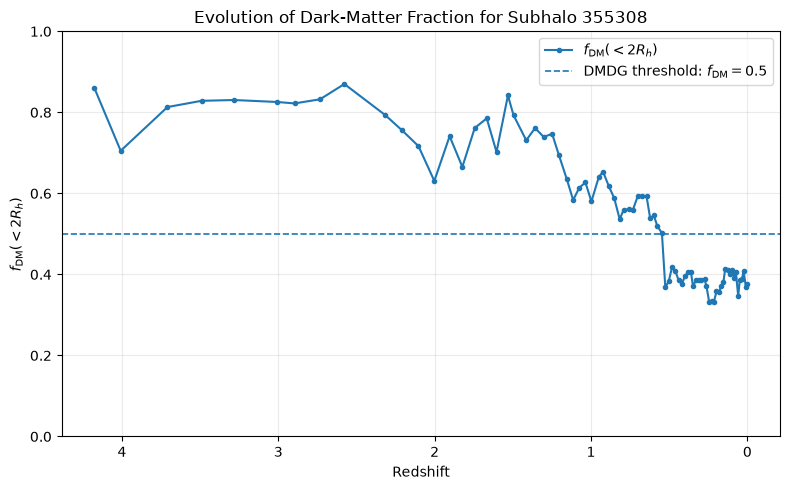

In [22]:
import matplotlib.pyplot as plt
plot_data = tree.dropna(subset=["Redshift", "f_DM"]).copy()
plot_data = plot_data.sort_values("Redshift", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    plot_data["Redshift"],
    plot_data["f_DM"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=r"$f_{\rm DM}(<2R_h)$"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label=r"DMDG threshold: $f_{\rm DM}=0.5$"
)
ax.invert_xaxis()
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$f_{\rm DM}(<2R_h)$")
ax.set_title("Evolution of Dark-Matter Fraction for Subhalo 355308")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()